<a href="https://colab.research.google.com/github/aliwritecode/Machine-Learning-Tutorial/blob/main/fraud_detection_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== DATA BEFORE SMOTE ===
defects
0    8779
1    2106
Name: count, dtype: int64


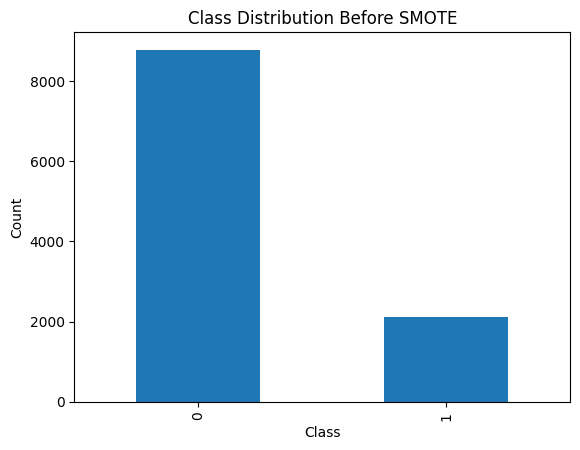


=== MATRIX BEFORE SMOTE ===


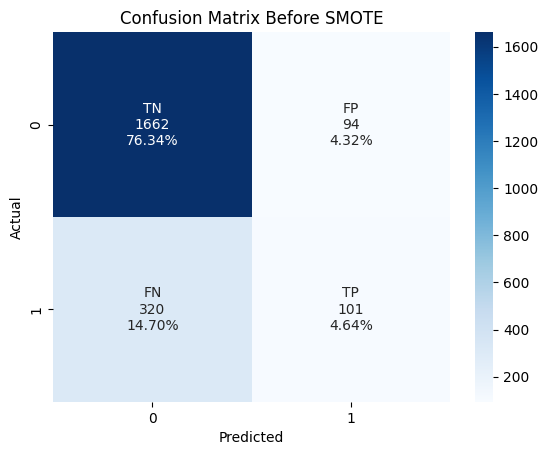


=== DATA AFTER SMOTE ===
defects
0    7023
1    7023
Name: count, dtype: int64


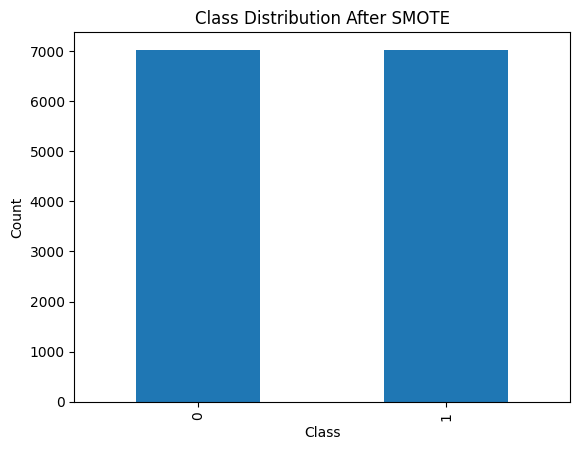


=== MATRIX AFTER SMOTE ===


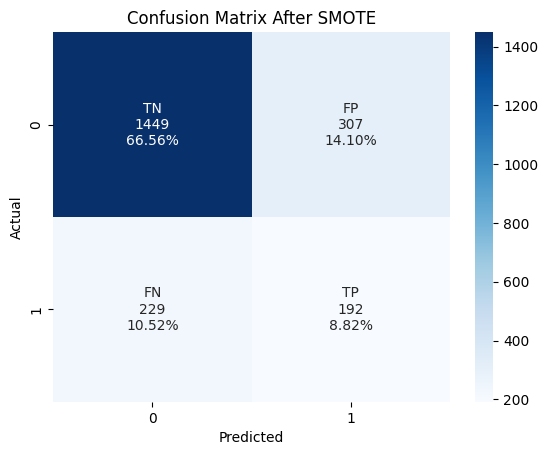

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE

# ===============================
# 1. LOAD RAW DATA (NO CHANGES)
# ===============================
df = pd.read_csv("/content/jm1.csv")

# ===============================
# 2. MINIMAL CLEANING (REQUIRED FOR MODEL ONLY)
# ===============================
df_model = df.replace('?', np.nan)
df_model = df_model.apply(pd.to_numeric)
df_model.fillna(df_model.median(), inplace=True)

# Target
df_model['defects'] = df_model['defects'].astype(int)

# ===============================
# 3. DATA BEFORE SMOTE
# ===============================
print("\n=== DATA BEFORE SMOTE ===")

counts_before = df_model['defects'].value_counts()
print(counts_before)

# Bar chart BEFORE SMOTE
plt.figure()
counts_before.plot(kind='bar')
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# ===============================
# PREPARE DATA
# ===============================
X = df_model.drop(columns=['defects'])
y = df_model['defects']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# FUNCTION: VISUAL CONFUSION MATRIX
# ===============================
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    total = cm.sum()

    labels = np.array([
        [f"TN\n{cm[0,0]}\n{cm[0,0]/total:.2%}",
         f"FP\n{cm[0,1]}\n{cm[0,1]/total:.2%}"],
        [f"FN\n{cm[1,0]}\n{cm[1,0]/total:.2%}",
         f"TP\n{cm[1,1]}\n{cm[1,1]/total:.2%}"]
    ])

    plt.figure()
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ===============================
# 4. RANDOM FOREST BEFORE SMOTE
# ===============================
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("\n=== MATRIX BEFORE SMOTE ===")
plot_conf_matrix(y_test, y_pred, "Confusion Matrix Before SMOTE")

# ===============================
# 5. APPLY SMOTE (ONLY HERE)
# ===============================
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# ===============================
# 6. DATA AFTER SMOTE
# ===============================
print("\n=== DATA AFTER SMOTE ===")

counts_after = pd.Series(y_train_sm).value_counts()
print(counts_after)

# Bar chart AFTER SMOTE
plt.figure()
counts_after.plot(kind='bar')
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# ===============================
# 7. RANDOM FOREST AFTER SMOTE
# ===============================
rf_sm = RandomForestClassifier(n_estimators=200, max_depth=10)
rf_sm.fit(X_train_sm, y_train_sm)

y_pred_sm = rf_sm.predict(X_test)

print("\n=== MATRIX AFTER SMOTE ===")
plot_conf_matrix(y_test, y_pred_sm, "Confusion Matrix After SMOTE")


=== PERFORMANCE COMPARISON ===
      Metric  Before SMOTE  After SMOTE
0   Accuracy      0.809830     0.753790
1  Precision      0.517949     0.384770
2     Recall      0.239905     0.456057
3   F1 Score      0.327922     0.417391


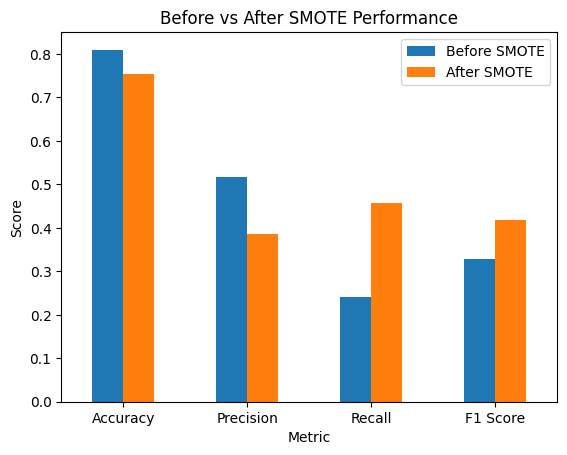

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# ===============================
# METRICS BEFORE SMOTE
# ===============================
acc_before = accuracy_score(y_test, y_pred)
prec_before = precision_score(y_test, y_pred)
rec_before = recall_score(y_test, y_pred)
f1_before = f1_score(y_test, y_pred)

# ===============================
# METRICS AFTER SMOTE
# ===============================
acc_after = accuracy_score(y_test, y_pred_sm)
prec_after = precision_score(y_test, y_pred_sm)
rec_after = recall_score(y_test, y_pred_sm)
f1_after = f1_score(y_test, y_pred_sm)

# ===============================
# COMPARISON TABLE
# ===============================
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Before SMOTE": [acc_before, prec_before, rec_before, f1_before],
    "After SMOTE": [acc_after, prec_after, rec_after, f1_after]
})

print("\n=== PERFORMANCE COMPARISON ===")
print(comparison)

# ===============================
# OPTIONAL: BAR CHART (VERY NICE FOR PRESENTATION)
# ===============================
comparison.set_index("Metric").plot(kind="bar")
plt.title("Before vs After SMOTE Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()